# Dynamic Time Warping 

### Import librairies 

In [22]:
import numpy as np
from dtw import *
from sklearn.decomposition import PCA
import scipy.io

# from numpy.linalg import norm

### Toy example

Step pattern recursion:
 g[i,j] = min(
     g[i-3,j-2] +     d[i-2,j-1] +     d[i-1,j  ] +     d[i  ,j  ] ,
     g[i-1,j-1] +     d[i  ,j  ] ,
     g[i-2,j-3] +     d[i-1,j-2] +     d[i  ,j-1] + 0 * d[i  ,j  ] ,
 ) 

Normalization hint: N



<Axes: xlabel='Query index', ylabel='Reference index'>

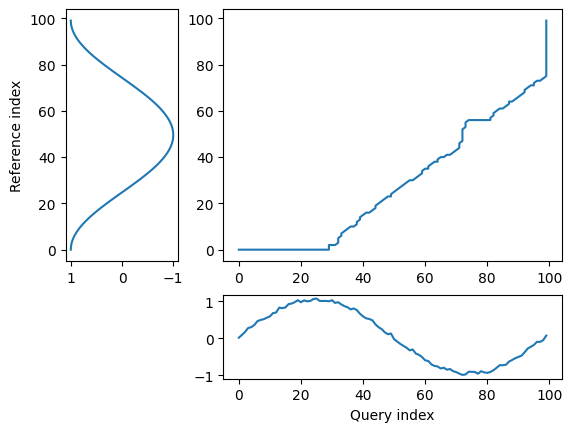

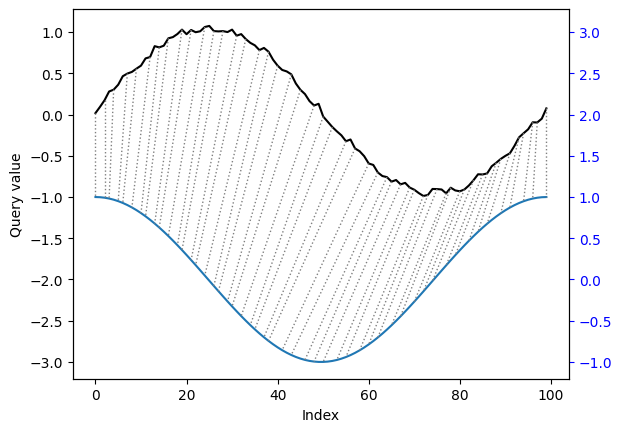

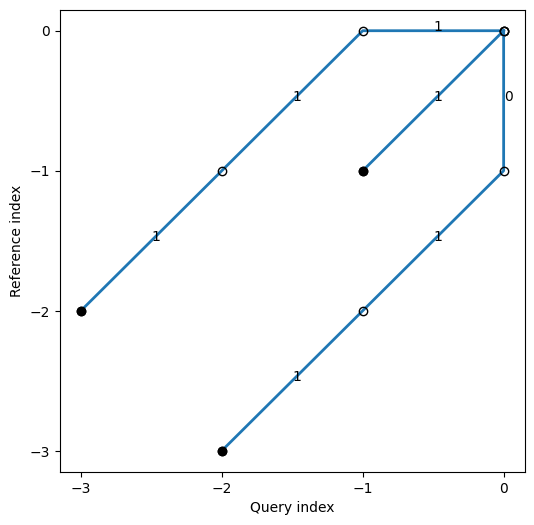

In [23]:
## A noisy sine wave as query
idx = np.linspace(0,6.28,num=100)
query = np.sin(idx) + np.random.uniform(size=100)/10.0

## A cosine is for template; sin and cos are offset by 25 samples
template = np.cos(idx)

## Find the best match with the canonical recursion formula
alignment = dtw(query, template, keep_internals=True)

## Display the warping curve, i.e. the alignment curve
alignment.plot(type="threeway")

## Align and plot with the Rabiner-Juang type VI-c unsmoothed recursion
dtw(query, template, keep_internals=True, 
    step_pattern=rabinerJuangStepPattern(6, "c"))\
    .plot(type="twoway",offset=-2)

## See the recursion relation, as formula and diagram
print(rabinerJuangStepPattern(6,"c"))
rabinerJuangStepPattern(6,"c").plot()

### First Try

shape of X8 =  (13,)
shape of X11 =  (11,)
Step pattern recursion:
 g[i,j] = min(
     g[i-3,j-2] +     d[i-2,j-1] +     d[i-1,j  ] +     d[i  ,j  ] ,
     g[i-1,j-1] +     d[i  ,j  ] ,
     g[i-2,j-3] +     d[i-1,j-2] +     d[i  ,j-1] + 0 * d[i  ,j  ] ,
 ) 

Normalization hint: N



<Axes: xlabel='Query index', ylabel='Reference index'>

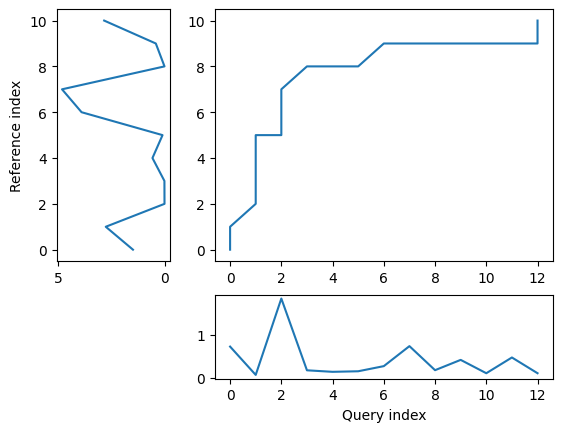

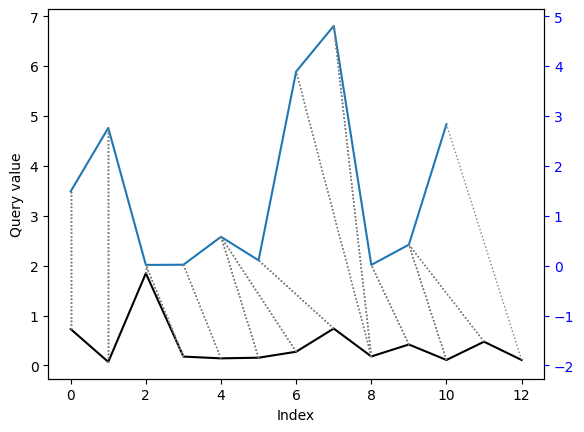

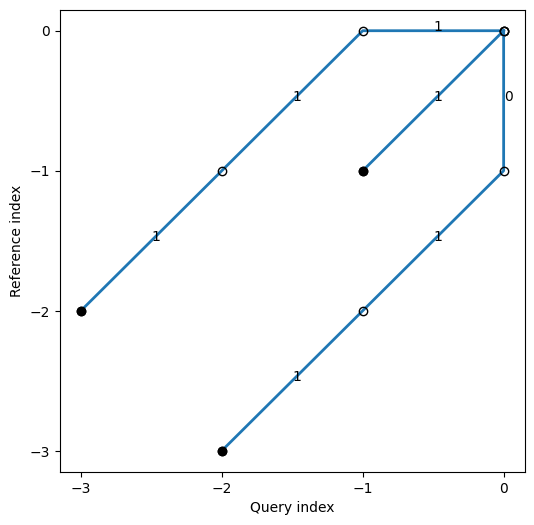

In [24]:
session = "run"
path_8 = "data/Rat8-20130713_proces_bin5.mat"
data_8 = scipy.io.loadmat(path_8)

path_11 = "data/Rat11-20150327_proces_bin5.mat"
data_11 = scipy.io.loadmat(path_11)

spk_sess_8 = data_8["spik"][session][0, 0].astype(float)   # neurons x T
# pos_sess = data["posit"][session][0, 0].astype(float)  # 2 x T on incorporera ça plus tard
# event_sess = data["event"][session][0, 0]              # 1 x T

spk_sess_11 = data_11["spik"][session][0, 0].astype(float)

# réduction (extrême) d'échantillons
X8 = spk_sess_8.mean(axis=1)
X11 = spk_sess_11.mean(axis=1)
 
# on divise par 20 les times bins
X8 = X8[::20]
X11 = X11[::20]

# 3. DTW avec contrainte
alignment = dtw(
    X8,
    X11,
    window_type="sakoechiba",
    window_args={"window_size": 100},
    keep_internals=True
)

alignment.plot(type="threeway")


print("shape of X8 = ", X8.shape)
print("shape of X11 = ", X11.shape)

dtw(X8, X11, keep_internals=True, step_pattern=rabinerJuangStepPattern(6, "c")).plot(type="twoway", offset=2)
print(rabinerJuangStepPattern(6, "c"))
rabinerJuangStepPattern(6, "c").plot()

Before puff shapes: (269, 10) (145, 10)
After puff shapes: (143, 10) (153, 10)
Final aligned shapes: (676, 10) (676, 10)


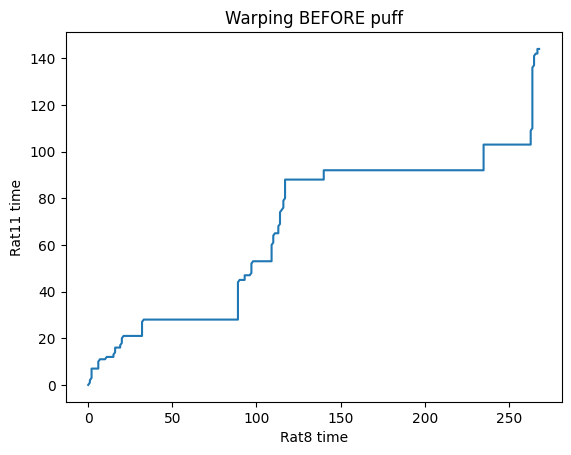

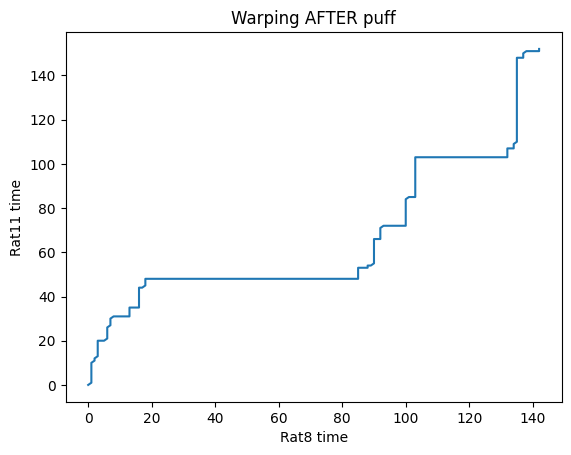

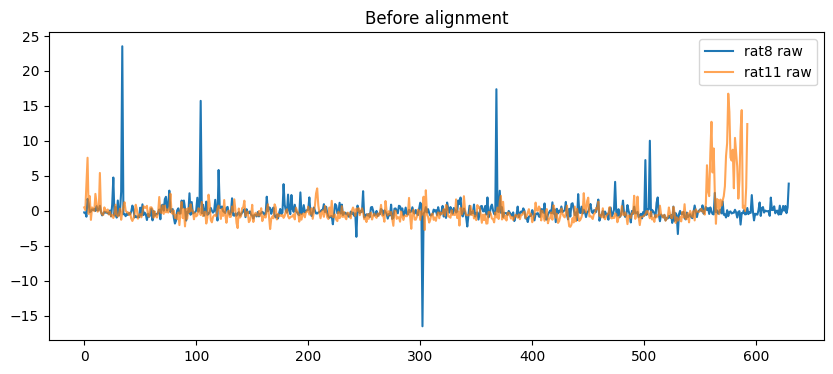

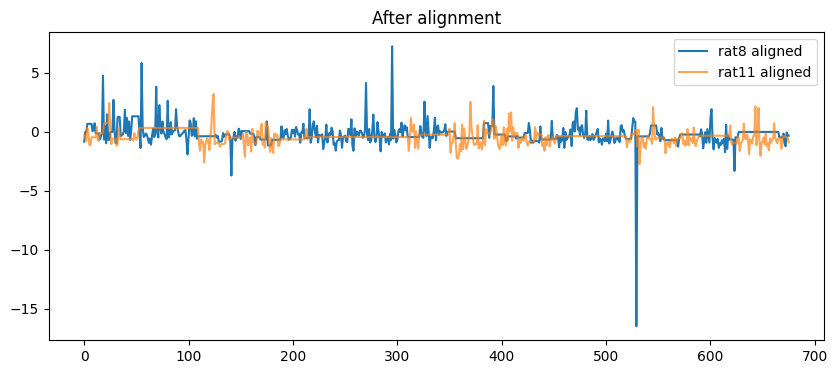

In [31]:
# ============================================================
# DTW ALIGNMENT PIPELINE (PCA commun → split puff → DTW → warp → concat)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from dtw import dtw

# ============================================================
# 1) HELPERS
# ============================================================

def extract_laps(pos, track_len=180):
    """
    Détecte les laps via les resets de position
    """
    laps = []
    start = 0

    for i in range(1, len(pos)):
        if pos[i] < pos[i-1]:  # reset de position → nouveau lap
            laps.append((start, i))
            start = i

    laps.append((start, len(pos)))
    return laps


def extract_relevant_laps(X, pos, puff_pos, window_cm=20, track_len=180):
    """
    Garde uniquement les laps qui passent proche du puff
    """
    laps = extract_laps(pos, track_len)
    delta = window_cm / track_len

    selected_segments = []

    for start, end in laps:
        lap_pos = pos[start:end]

        # condition : lap passe dans la zone puff
        if np.any((lap_pos >= puff_pos - delta) & (lap_pos <= puff_pos + delta)):
            selected_segments.append(X[start:end])

    if len(selected_segments) == 0:
        raise ValueError("No relevant laps found")

    return np.vstack(selected_segments)

def build_separate_pca(X8, X11, n_components=10):

    scaler8 = StandardScaler()
    scaler11 = StandardScaler()

    X8_z = scaler8.fit_transform(X8)
    X11_z = scaler11.fit_transform(X11)

    pca8 = PCA(n_components=n_components)
    pca11 = PCA(n_components=n_components)

    X8_pca = pca8.fit_transform(X8_z)
    X11_pca = pca11.fit_transform(X11_z)

    return X8_pca, X11_pca


def split_around_puff(X, pos, puff_pos, window_cm=20, track_len=180):
    delta = window_cm / track_len

    before_mask = (pos >= puff_pos - delta) & (pos <= puff_pos)
    after_mask  = (pos >= puff_pos) & (pos <= puff_pos + delta)

    return X[before_mask], X[after_mask]


def compute_dtw(X1, X2, window=200):
    return dtw(
        X1, X2,
        keep_internals=True,
        window_type="sakoechiba",
        window_args={"window_size": window}
    )


def warp_signals(X1, X2, alignment):
    path1 = alignment.index1
    path2 = alignment.index2

    return X1[path1], X2[path2]


# ============================================================
# 2) MAIN FUNCTION
# ============================================================

def align_two_rats(spk8, spk11, pos8, pos11, puff8, puff11,
                   n_components=10, downsample=10):

    # ---- transpose (time x neurons)
    X8 = spk8.T
    X11 = spk11.T

    pos8 = pos8.flatten()
    pos11 = pos11.flatten()

    # ---- downsample (VERY IMPORTANT)
    X8 = X8[::downsample]
    X11 = X11[::downsample]
    pos8 = pos8[::downsample]
    pos11 = pos11[::downsample]

    # ---- garder uniquement les laps pertinents
    X8 = extract_relevant_laps(X8, pos8, puff8)
    X11 = extract_relevant_laps(X11, pos11, puff11)

    pos8 = extract_relevant_laps(pos8.reshape(-1,1), pos8, puff8).flatten()
    pos11 = extract_relevant_laps(pos11.reshape(-1,1), pos11, puff11).flatten()

    # ---- PCA
    X8_pca, X11_pca = build_separate_pca(X8, X11, n_components)

    # ---- split autour puff
    X8_b, X8_a = split_around_puff(X8_pca, pos8, puff8)
    X11_b, X11_a = split_around_puff(X11_pca, pos11, puff11)

    print("Before puff shapes:", X8_b.shape, X11_b.shape)
    print("After puff shapes:", X8_a.shape, X11_a.shape)

    # ---- DTW séparé
    align_b = compute_dtw(X8_b, X11_b)
    align_a = compute_dtw(X8_a, X11_a)

    # ---- warp
    X8_b_al, X11_b_al = warp_signals(X8_b, X11_b, align_b)
    X8_a_al, X11_a_al = warp_signals(X8_a, X11_a, align_a)

    # ---- concat
    X8_final = np.vstack([X8_b_al, X8_a_al])
    X11_final = np.vstack([X11_b_al, X11_a_al])

    print("Final aligned shapes:", X8_final.shape, X11_final.shape)

    # ============================================================
    # 3) PLOTS
    # ============================================================

    # ---- warping function
    plt.figure()
    plt.plot(align_b.index1, align_b.index2)
    plt.title("Warping BEFORE puff")
    plt.xlabel("Rat8 time")
    plt.ylabel("Rat11 time")

    plt.figure()
    plt.plot(align_a.index1, align_a.index2)
    plt.title("Warping AFTER puff")
    plt.xlabel("Rat8 time")
    plt.ylabel("Rat11 time")

    # ---- signal comparison (PC1)
    plt.figure(figsize=(10,4))
    plt.plot(X8_pca[:,0], label="rat8 raw")
    plt.plot(X11_pca[:,0], label="rat11 raw", alpha=0.7)
    plt.legend()
    plt.title("Before alignment")

    plt.figure(figsize=(10,4))
    plt.plot(X8_final[:,0], label="rat8 aligned")
    plt.plot(X11_final[:,0], label="rat11 aligned", alpha=0.7)
    plt.legend()
    plt.title("After alignment")

    plt.show()

    return X8_final, X11_final


# ============================================================
# 3) USAGE EXAMPLE
# ============================================================

# spk_sess_8, spk_sess_11 : neurons x T
# pos_sess_8, pos_sess_11 : 2 x T
# puff positions déjà calculées (comme dans ton code)

session = "run"
path_8 = "data/Rat8-20130713_proces_bin5.mat"
data_8 = scipy.io.loadmat(path_8)

path_11 = "data/Rat11-20150327_proces_bin5.mat"
data_11 = scipy.io.loadmat(path_11)

spk_sess_8 = data_8["spik"][session][0, 0].astype(float)   # neurons x T
pos_sess_8 = data_8["posit"][session][0, 0].astype(float)  # 2 x T on incorporera ça plus tard
# event_sess = data["event"][session][0, 0]              # 1 x T

spk_sess_11 = data_11["spik"][session][0, 0].astype(float)
pos_sess_11 = data_11["posit"][session][0, 0].astype(float)  # 2 x T on incorporera ça plus tard

X8_aligned, X11_aligned = align_two_rats(
    spk_sess_8,
    spk_sess_11,
    pos_sess_8[0],
    pos_sess_11[0],
    puff8=0.62,   # à remplacer par ton vrai pos_puff
    puff11=0.34,
    n_components=10,
    downsample=10
)